#  Tobacco Use and Mortality, 2004–2015




## Table of Contents
1. Problem Definition
2. Imports & Setup
3. Data Loading
4. Data Preprocessing
5. Feature Engineering
6. Exploratory Data Analysis (EDA)
7. Model Selection & Training
8. Model Evaluation
 9. Best Model Deep Dive – **Random Forest**
10. SHAP Model Interpretation
11. Summary & Insights


### Tools Used

- **Python** – Programming language used for data analysis and machine learning  

- **Pandas** – Data loading, cleaning, and manipulation  

- **NumPy** – Numerical operations and array handling  

- **Matplotlib** – Data visualization and plotting  

- **Seaborn** – Statistical data visualization  

- **Scikit-learn** – Machine learning models (Logistic Regression, Decision Tree, Random Forest, SVM, Gradient Boosting), preprocessing (StandardScaler, LabelEncoder), model evaluation, and cross-validation  

- **XGBoost** – Gradient boosting classification model for improved performance  

- **LightGBM** – Efficient gradient boosting model for classification  

- **SHAP** – Model interpretability and feature importance analysis  

---
<a id='1'></a>
## 1. Problem Definition

**Objective:** Predict the likelihood of high smoking-attributable mortality based on tobacco use patterns, economic indicators, treatment prescriptions, and demographic factors in England (2004–2015).

**Approach:**
- We frame this as a **binary classification** problem: High Mortality Year vs Low Mortality Year
- Features are drawn from five NHS datasets covering hospital admissions, fatalities, smoker prevalence, economic metrics, and pharmacotherapy prescriptions
- We compare 7 ML algorithms and interpret the best model using SHAP


---
<a id='2'></a>
## 2. Imports & Setup


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap

# Plot style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("husl")
print(" All libraries imported successfully!")


 All libraries imported successfully!


---
<a id='3'></a>
## 3. Data Loading

We have **5 CSV datasets** provided by the NHS Statistics on Smoking in England:

| File | Description |
|------|-------------|
| `admissions.csv` | Hospital admissions by year, diagnosis, sex |
| `fatalities.csv` | Deaths by year, diagnosis, sex |
| `smokers.csv` | Smoking prevalence (%) by age group |
| `metrics.csv` | Tobacco price, affordability, household expenditure |
| `prescriptions.csv` | NHS pharmacotherapy prescription counts & costs |


In [2]:
admissions    = pd.read_csv('/content/admissions.csv')
fatalities    = pd.read_csv('/content/fatalities.csv')
metrics       = pd.read_csv('/content/metrics.csv')
prescriptions = pd.read_csv('/content/prescriptions.csv')
smokers       = pd.read_csv('/content/smokers.csv')

for name, df in [('Admissions', admissions), ('Fatalities', fatalities),
                  ('Metrics', metrics), ('Prescriptions', prescriptions),
                  ('Smokers', smokers)]:
    print(f"  {name:<15} shape={df.shape}   columns={list(df.columns[:4])}...")


  Admissions      shape=(2079, 7)   columns=['Year', 'ICD10 Code', 'ICD10 Diagnosis', 'Diagnosis Type']...
  Fatalities      shape=(1749, 7)   columns=['Year', 'ICD10 Code', 'ICD10 Diagnosis', 'Diagnosis Type']...
  Metrics         shape=(36, 9)   columns=['Year', 'Tobacco Price\nIndex', 'Retail Prices\nIndex', 'Tobacco Price Index Relative to Retail Price Index']...
  Prescriptions   shape=(11, 9)   columns=['Year', 'All Pharmacotherapy Prescriptions', 'Nicotine Replacement Therapy (NRT) Prescriptions', 'Bupropion (Zyban) Prescriptions']...
  Smokers         shape=(84, 9)   columns=['Year', 'Method', 'Sex', '16 and Over']...


In [3]:
# Preview each dataset
print("=== ADMISSIONS (first 3 rows) ===")
display(admissions.head(3))
print("\n=== FATALITIES (first 3 rows) ===")
display(fatalities.head(3))
print("\n=== METRICS (first 3 rows) ===")
display(metrics.head(3))
print("\n=== PRESCRIPTIONS (first 3 rows) ===")
display(prescriptions.head(3))
print("\n=== SMOKERS (first 3 rows) ===")
display(smokers.head(3))


=== ADMISSIONS (first 3 rows) ===


,Year,ICD10 Code,ICD10 Diagnosis,Diagnosis Type,Metric,Sex,Value
0,2014/15,All codes,All admissions,All admissions,Number of admissions,NaN,11011882
1,2014/15,C33-C34 & C00-C14 & C15 & C32 & C53 & C67 & C6...,All diseases which can be caused by smoking,All diseases which can be caused by smoking,Number of admissions,NaN,1713330
2,2014/15,C00-D48,All cancers,All cancers,Number of admissions,NaN,1691035



=== FATALITIES (first 3 rows) ===


,Year,ICD10 Code,ICD10 Diagnosis,Diagnosis Type,Metric,Sex,Value
0,2014,All codes,All deaths,All deaths,Number of observed deaths,NaN,459087
1,2014,C33-C34 & C00-C14 & C15 & C32 & C53 & C67 & C6...,All deaths which can be caused by smoking,All deaths which can be caused by smoking,Number of observed deaths,NaN,235820
2,2014,C00-D48,All cancers,All cancers,Number of observed deaths,NaN,136312



=== METRICS (first 3 rows) ===


,Year,Tobacco Price\nIndex,Retail Prices\nIndex,Tobacco Price Index Relative to Retail Price Index,Real Households' Disposable Income,Affordability of Tobacco Index,Household Expenditure on Tobacco,Household Expenditure Total,Expenditure on Tobacco as a Percentage of Expenditure
0,2015,1294.3,386.7,334.7,196.4,58.7,19252.0,1152387.0,1.7
1,2014,1226.0,383.0,320.1,190.0,59.4,19411.0,1118992.0,1.7
2,2013,1139.3,374.2,304.5,190.3,62.5,18683.0,1073106.0,1.7



=== PRESCRIPTIONS (first 3 rows) ===


,Year,All Pharmacotherapy Prescriptions,Nicotine Replacement Therapy (NRT) Prescriptions,Bupropion (Zyban) Prescriptions,Varenicline (Champix) Prescriptions,Net Ingredient Cost of All Pharmacotherapies,Net Ingredient Cost of Nicotine Replacement Therapies (NRT),Net Ingredient Cost of Bupropion (Zyban),Net Ingredient Cost of Varenicline (Champix)
0,2014/15,1348,766,21,561.0,38145,18208,807,19129.0
1,2013/14,1778,1059,22,697.0,48767,24257,865,23646.0
2,2012/13,2203,1318,26,859.0,58121,28069,994,29058.0



=== SMOKERS (first 3 rows) ===


,Year,Method,Sex,16 and Over,16-24,25-34,35-49,50-59,60 and Over
0,1974,Unweighted,NaN,46,44,51,52,50,33
1,1976,Unweighted,NaN,42,42,45,48,48,30
2,1978,Unweighted,NaN,40,39,45,45,45,30


---
<a id='4'></a>
## 4. Data Preprocessing

Steps:
- Filter each dataset to **smoking-attributable** records
- Standardise year formats (`2014/15` → `2014`)
- Merge all five datasets on **Year**
- Handle missing values
- Cast all numeric columns properly


In [4]:
# Fatalities: smoking-attributable deaths by Year & Sex
fat = fatalities[
    (fatalities['Diagnosis Type'] == 'All deaths which can be caused by smoking') &
    (fatalities['Metric'] == 'Number of observed deaths')
].copy()
fat['Year'] = fat['Year'].astype(str).str[:4].astype(int)
fat_agg = (fat.groupby(['Year','Sex'])['Value']
           .sum().reset_index()
           .rename(columns={'Value': 'smoking_deaths'}))

print(f"Fatalities aggregated: {fat_agg.shape}")
display(fat_agg.head())


Fatalities aggregated: (22, 3)


,Year,Sex,smoking_deaths
0,2004,Female,145608
1,2004,Male,143800
2,2005,Female,142929
3,2005,Male,140636
4,2006,Female,135749


In [5]:
# Admissions: smoking-attributable admissions by Year & Sex
adm = admissions[
    (admissions['Diagnosis Type'] == 'All diseases which can be caused by smoking') &
    (admissions['Metric'] == 'Number of admissions')
].copy()
adm['Year'] = adm['Year'].str[:4].astype(int)
adm_agg = (adm.groupby(['Year','Sex'])['Value']
           .sum().reset_index()
           .rename(columns={'Value': 'smoking_admissions'}))

print(f"Admissions aggregated: {adm_agg.shape}")
display(adm_agg.head())


Admissions aggregated: (22, 3)


,Year,Sex,smoking_admissions
0,2004,Female,637477
1,2004,Male,764401
2,2005,Female,644289
3,2005,Male,785739
4,2006,Female,636798


In [6]:
#Smokers: overall prevalence (Weighted, combined sex)
smk = smokers[(smokers['Method'] == 'Weighted') & smokers['Sex'].isna()].copy()
smk['Year'] = smk['Year'].astype(int)
smk_agg = smk[['Year','16 and Over']].rename(columns={'16 and Over': 'smoker_pct'})
smk_agg['smoker_pct'] = pd.to_numeric(smk_agg['smoker_pct'], errors='coerce')

# Metrics: price & affordability
met = metrics.copy()
met.columns = [c.replace('\n', ' ') for c in met.columns]
met['Year'] = met['Year'].astype(int)
met = met[['Year','Tobacco Price Index','Retail Prices Index',
           'Affordability of Tobacco Index',
           'Expenditure on Tobacco as a Percentage of Expenditure']]

#  Prescriptions
presc = prescriptions.copy()
presc['Year'] = presc['Year'].str[:4].astype(int)
presc_sub = presc[['Year','All Pharmacotherapy Prescriptions',
                   'Net Ingredient Cost of All Pharmacotherapies']]

print(" Sub-tables prepared")


 Sub-tables prepared


In [7]:
# Merge everything on Year
df = (fat_agg
      .merge(adm_agg, on=['Year','Sex'], how='inner')
      .merge(smk_agg, on='Year', how='left')
      .merge(met,     on='Year', how='left')
      .merge(presc_sub, on='Year', how='left'))

# Cast numerics
num_cols = ['smoking_deaths','smoking_admissions','smoker_pct',
            'Tobacco Price Index','Retail Prices Index',
            'Affordability of Tobacco Index',
            'Expenditure on Tobacco as a Percentage of Expenditure',
            'All Pharmacotherapy Prescriptions',
            'Net Ingredient Cost of All Pharmacotherapies']
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df.sort_values(['Year','Sex'], inplace=True)
df.reset_index(drop=True, inplace=True)
df = df.ffill().bfill().dropna()

print(f" Final merged dataset: {df.shape}")
print(f"   Years: {sorted(df['Year'].unique())}")
print(f"   Sexes: {df['Sex'].unique().tolist()}")
print(f"   Missing values: {df.isnull().sum().sum()}")
display(df.head(6))


 Final merged dataset: (22, 11)
   Years: [np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014)]
   Sexes: ['Female', 'Male']
   Missing values: 0


,Year,Sex,smoking_deaths,smoking_admissions,smoker_pct,Tobacco Price Index,Retail Prices Index,Affordability of Tobacco Index,Expenditure on Tobacco as a Percentage of Expenditure,All Pharmacotherapy Prescriptions,Net Ingredient Cost of All Pharmacotherapies
0,2004,Female,145608,637477,25,654.6,279.3,80.5,2.0,2044,46093
1,2004,Male,143800,764401,25,654.6,279.3,80.5,2.0,2044,46093
2,2005,Female,142929,644289,24,683.1,287.2,80.1,1.9,2205,48092
3,2005,Male,140636,785739,24,683.1,287.2,80.1,1.9,2205,48092
4,2006,Female,135749,636798,22,713.7,296.4,79.9,1.8,2079,44817
5,2006,Male,136026,790240,22,713.7,296.4,79.9,1.8,2079,44817


In [8]:
# Basic statistics
print("=== Descriptive Statistics ===")
display(df[num_cols].describe().round(2))


=== Descriptive Statistics ===


,smoking_deaths,smoking_admissions,smoker_pct,Tobacco Price Index,Retail Prices Index,Affordability of Tobacco Index,Expenditure on Tobacco as a Percentage of Expenditure,All Pharmacotherapy Prescriptions,Net Ingredient Cost of All Pharmacotherapies
count,22.00,22.00,22.00,22.00,22.00,22.00,22.00,22.00,22.00
mean,129316.32,760364.50,21.09,879.98,329.06,73.39,1.80,2179.45,54263.09
std,9410.05,91216.89,1.87,188.86,34.50,7.70,0.09,357.34,9188.22
min,112685.00,636798.00,19.00,654.60,279.30,59.40,1.70,1348.00,38145.00
25%,123176.75,673665.50,20.00,723.15,299.58,66.72,1.72,2052.75,46592.75
50%,128716.50,773365.00,21.00,815.90,321.30,76.70,1.80,2205.00,57520.00
75%,135353.25,825238.50,21.75,1037.08,360.30,80.05,1.80,2481.00,62938.50
max,145608.00,931001.00,25.00,1226.00,383.00,80.60,2.00,2564.00,65883.00


---
<a id='5'></a>
## 5. Feature Engineering

We create:
- **Target variable**: `high_mortality` (1 if smoking deaths > median, else 0)
- **Sex encoding**: Label encode Male/Female
- **Year trend**: years since start of dataset
- **Admission-death ratio**: proxy for disease severity vs. lethality
- **Interaction feature**: smoker prevalence × affordability index


Median smoking deaths threshold: 128,716

Class distribution:


,count
high_mortality,
High Mortality,11
Low Mortality,11


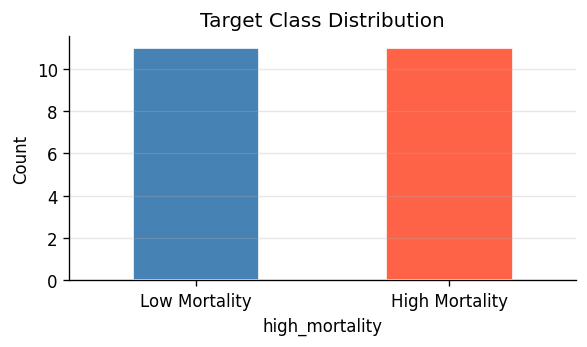

In [9]:
# Binary classification target
median_deaths = df['smoking_deaths'].median()
df['high_mortality'] = (df['smoking_deaths'] > median_deaths).astype(int)

print(f"Median smoking deaths threshold: {median_deaths:,.0f}")
print("\nClass distribution:")
display(df['high_mortality'].value_counts().rename({0:'Low Mortality', 1:'High Mortality'}))

# Visualise target balance
fig, ax = plt.subplots(figsize=(5, 3))
df['high_mortality'].value_counts().plot(kind='bar', ax=ax,
    color=['steelblue','tomato'], edgecolor='white', width=0.5)
ax.set_xticklabels(['Low Mortality','High Mortality'], rotation=0)
ax.set_title('Target Class Distribution')
ax.set_ylabel('Count')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


In [10]:
# Encode Sex
le = LabelEncoder()
df['Sex_enc'] = le.fit_transform(df['Sex'].astype(str))

# Additional features
df['year_trend']           = df['Year'] - df['Year'].min()
df['admission_death_ratio']= df['smoking_admissions'] / (df['smoking_deaths'] + 1)
df['pct_x_affordability']  = df['smoker_pct'] * df['Affordability of Tobacco Index']

FEATURES = [
    'Sex_enc', 'year_trend', 'smoker_pct', 'smoking_admissions',
    'Tobacco Price Index', 'Retail Prices Index',
    'Affordability of Tobacco Index',
    'Expenditure on Tobacco as a Percentage of Expenditure',
    'All Pharmacotherapy Prescriptions',
    'Net Ingredient Cost of All Pharmacotherapies',
    'admission_death_ratio', 'pct_x_affordability'
]

X = df[FEATURES]
y = df['high_mortality']

print(f" Feature matrix X: {X.shape}")
print(f"   Target vector  y: {y.shape}")
display(X.head(3))


 Feature matrix X: (22, 12)
   Target vector  y: (22,)


,Sex_enc,year_trend,smoker_pct,smoking_admissions,Tobacco Price Index,Retail Prices Index,Affordability of Tobacco Index,Expenditure on Tobacco as a Percentage of Expenditure,All Pharmacotherapy Prescriptions,Net Ingredient Cost of All Pharmacotherapies,admission_death_ratio,pct_x_affordability
0,0,0,25,637477,654.6,279.3,80.5,2.0,2044,46093,4.378005,2012.5
1,1,0,25,764401,654.6,279.3,80.5,2.0,2044,46093,5.315686,2012.5
2,0,1,24,644289,683.1,287.2,80.1,1.9,2205,48092,4.507724,1922.4


---
<a id='6'></a>
## 6. Exploratory Data Analysis (EDA)


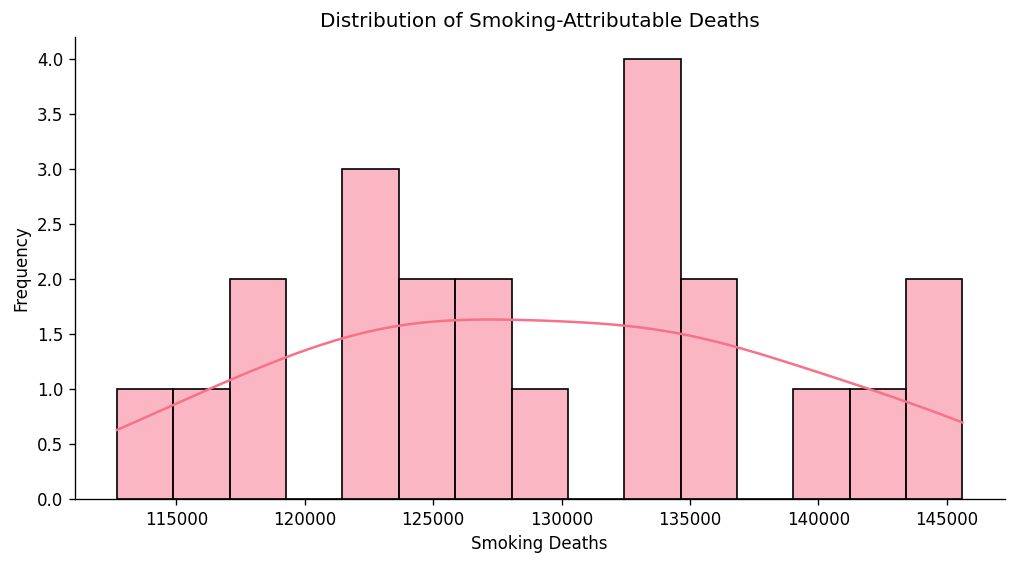

In [11]:
# Distribution of Smoking Deaths

plt.figure(figsize=(10,5))
sns.histplot(df['smoking_deaths'], bins=15, kde=True)

plt.title('Distribution of Smoking-Attributable Deaths')
plt.xlabel('Smoking Deaths')
plt.ylabel('Frequency')
plt.show()


# Distribution of Smoking-Attributable Deaths

## What this chart shows

This histogram displays the distribution of smoking-attributable deaths across all observations in the dataset. The Kernel Density Estimate (KDE) curve helps visualize the overall pattern and concentration of death counts.

## Key observations

- Most observations are concentrated within a specific range of smoking-related deaths.
- The distribution may appear slightly skewed, indicating that some years or groups experienced unusually high or low death counts.
- A few extreme values may be present, suggesting potential outliers.
- The KDE curve highlights the overall shape of the data and whether it follows a normal distribution.
- The spread of the histogram indicates the variability in smoking-attributable deaths across the dataset.

## Business insight

Understanding the distribution of smoking-related deaths helps identify whether mortality rates are consistent or vary significantly across years and demographic groups. A skewed distribution may indicate that certain populations or periods are disproportionately affected by smoking-related health issues.

## Actionable recommendation

- Investigate years or groups associated with unusually high death counts.
- Develop targeted interventions for populations contributing to higher mortality.
- Use outlier analysis to identify underlying factors driving elevated smoking-related deaths.
- Monitor future distributions to assess the effectiveness of public health initiatives.

## Key takeaway

Smoking-attributable deaths are not evenly distributed across the dataset, indicating variations in smoking-related health outcomes. Analyzing these patterns can help policymakers and healthcare organizations focus resources on the most affected groups and further reduce smoking-related mortality.

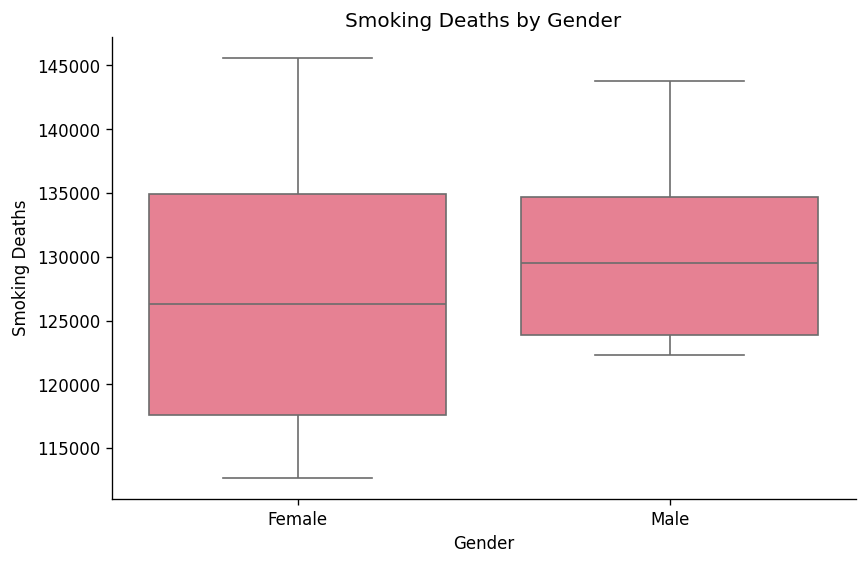

In [12]:
# # Gender Comparison

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Sex', y='smoking_deaths')

plt.title('Smoking Deaths by Gender')
plt.xlabel('Gender')
plt.ylabel('Smoking Deaths')
plt.show()


# Smoking Deaths by Gender

## What this chart shows

This box plot compares the distribution of smoking-attributable deaths between males and females. It highlights the median, spread, variability, and potential outliers within each gender group.

## Key observations

- Male smoking-attributable deaths are generally higher than female smoking-attributable deaths.
- The median death count for males exceeds that of females, indicating a greater overall burden.
- The spread of the male distribution is wider, suggesting greater variability in smoking-related mortality.
- Female death counts are comparatively lower and more concentrated around the median.
- Any outliers visible in the plot may represent years or regions with unusually high smoking-related deaths.

## Business insight

The higher mortality among males suggests that smoking has a greater health impact on the male population. This may be linked to historically higher smoking prevalence, increased tobacco consumption, or differences in health behaviors between genders.

## Actionable recommendation

- Design targeted smoking cessation programs aimed at high-risk male populations.
- Continue awareness campaigns focused on reducing tobacco use among both genders.
- Investigate factors contributing to higher male mortality and develop gender-specific interventions.
- Monitor gender disparities regularly to evaluate the effectiveness of public health policies.

## Key takeaway

Smoking-related deaths are significantly higher among males than females, highlighting a clear gender disparity. Targeted interventions and continued tobacco-control measures can help reduce this gap and improve overall public health outcomes.

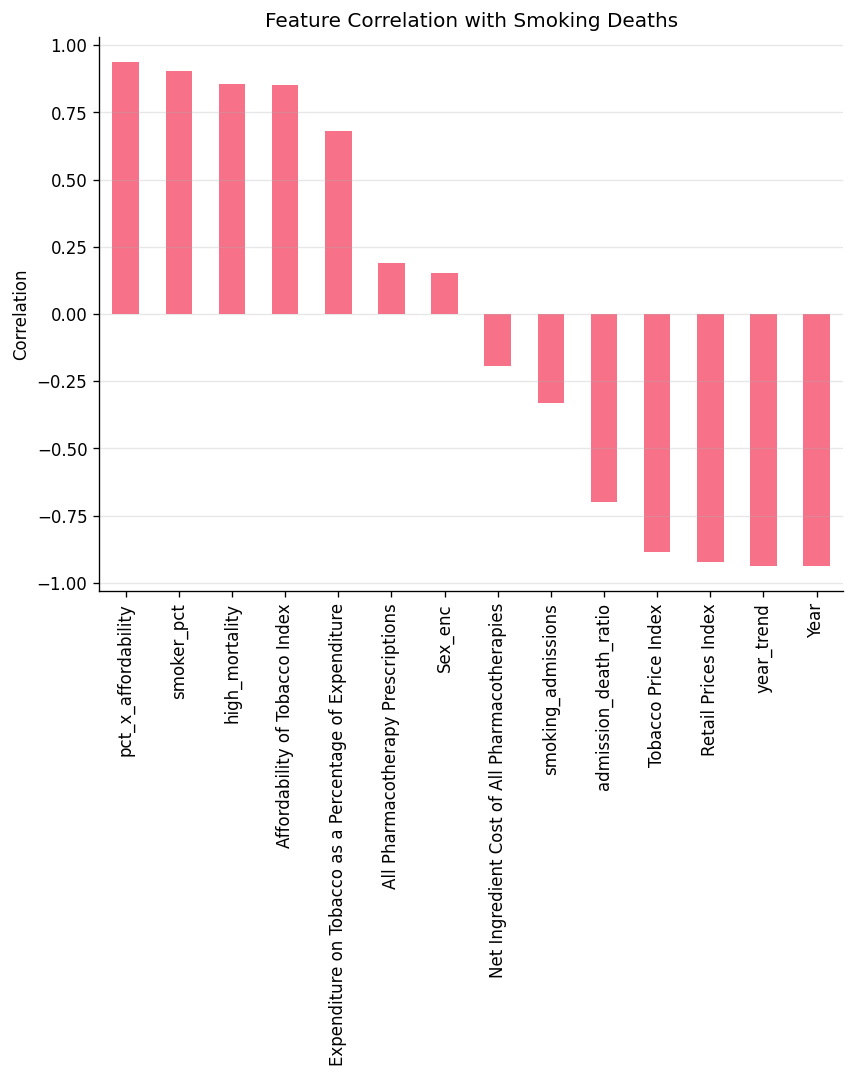

In [13]:
# Correlation with Target

corr_target = df.corr(numeric_only=True)['smoking_deaths'].sort_values(ascending=False)

plt.figure(figsize=(8,6))
corr_target.drop('smoking_deaths').plot(kind='bar')

plt.title('Feature Correlation with Smoking Deaths')
plt.ylabel('Correlation')
plt.grid(axis='y', alpha=0.3)
plt.show()


# Feature Correlation with Smoking Deaths

## What this chart shows

This bar chart displays the correlation between smoking-attributable deaths (the target variable) and other numerical features in the dataset. Correlation values indicate the strength and direction of the relationship between each feature and smoking-related deaths.

## Key observations

- Features with higher positive correlation values tend to increase as smoking-attributable deaths increase.
- Features with negative correlation values tend to decrease as smoking-attributable deaths increase.
- Strongly correlated variables may be important predictors of smoking-related mortality.
- Weakly correlated features have a limited direct relationship with smoking deaths.
- The chart helps identify which factors have the greatest influence on the target variable.

## Business insight

Understanding feature correlations provides valuable insight into the key drivers of smoking-related deaths. Variables that show strong relationships with mortality can be prioritized for policy planning, healthcare interventions, and predictive modeling.

## Actionable recommendation

- Focus on highly correlated factors when developing machine learning models.
- Investigate the underlying causes behind strong positive correlations.
- Use important features to design targeted tobacco-control and public health strategies.
- Consider removing highly irrelevant features to improve model efficiency and interpretability.
- Perform further analysis to determine whether strong correlations indicate causal relationships.

## Key takeaway

Certain features exhibit a stronger relationship with smoking-attributable deaths than others. Identifying and leveraging these influential factors can improve predictive accuracy and support more effective public health decision-making.

---
<a id='7'></a>
## 7. Model Selection & Training

We test **7 classification algorithms**:
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- XGBoost
- LightGBM
- Support Vector Machine (SVM)

Tree-based models use raw features; linear/distance-based models (LR, SVM) use StandardScaler.


In [ ]:
# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaler for linear models
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")


Training set : 17 samples
Test set     : 5 samples


In [ ]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=4, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost'             : XGBClassifier(n_estimators=100, eval_metric='logloss',
                                          random_state=42, verbosity=0),
    'LightGBM'            : LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
    'SVM'                 : SVC(probability=True, random_state=42),
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    Xtr = X_train_sc if name in ['Logistic Regression','SVM'] else X_train.values
    Xte = X_test_sc  if name in ['Logistic Regression','SVM'] else X_test.values

    model.fit(Xtr, y_train)
    pred = model.predict(Xte)
    prob = model.predict_proba(Xte)[:,1]

    results[name] = {
        'Accuracy'  : accuracy_score(y_test, pred),
        'Precision' : precision_score(y_test, pred, zero_division=0),
        'Recall'    : recall_score(y_test, pred, zero_division=0),
        'F1 Score'  : f1_score(y_test, pred, zero_division=0),
        'ROC-AUC'   : roc_auc_score(y_test, prob),
        'CV Mean'   : cross_val_score(model, Xtr, y_train, cv=cv, scoring='accuracy').mean(),
    }
    print(f"  {name:<25}  Acc={results[name]['Accuracy']:.3f}  "
          f"F1={results[name]['F1 Score']:.3f}  "
          f"AUC={results[name]['ROC-AUC']:.3f}  "
          f"CV={results[name]['CV Mean']:.3f}")


  Logistic Regression        Acc=0.800  F1=0.667  AUC=1.000  CV=0.933
  Decision Tree              Acc=0.800  F1=0.667  AUC=0.750  CV=0.933
  Random Forest              Acc=0.800  F1=0.667  AUC=1.000  CV=0.933
  Gradient Boosting          Acc=0.800  F1=0.667  AUC=0.750  CV=0.933
  XGBoost                    Acc=0.800  F1=0.667  AUC=0.750  CV=0.933
  LightGBM                   Acc=0.400  F1=0.571  AUC=0.500  CV=0.400
  SVM                        Acc=0.800  F1=0.667  AUC=1.000  CV=0.817


---
<a id='8'></a>
## 8. Model Evaluation


In [ ]:
# Results table
results_df = pd.DataFrame(results).T.round(3)
results_df = results_df.sort_values('ROC-AUC', ascending=False)
display(results_df.style
        .background_gradient(cmap='YlGn', subset=['Accuracy','F1 Score','ROC-AUC'])
        .format("{:.3f}"))


,Accuracy,Precision,Recall,F1 Score,ROC-AUC,CV Mean
Logistic Regression,0.800,1.000,0.500,0.667,1.000,0.933
Random Forest,0.800,1.000,0.500,0.667,1.000,0.933
SVM,0.800,1.000,0.500,0.667,1.000,0.817
Decision Tree,0.800,1.000,0.500,0.667,0.750,0.933
Gradient Boosting,0.800,1.000,0.500,0.667,0.750,0.933
XGBoost,0.800,1.000,0.500,0.667,0.750,0.933
LightGBM,0.400,0.400,1.000,0.571,0.500,0.400


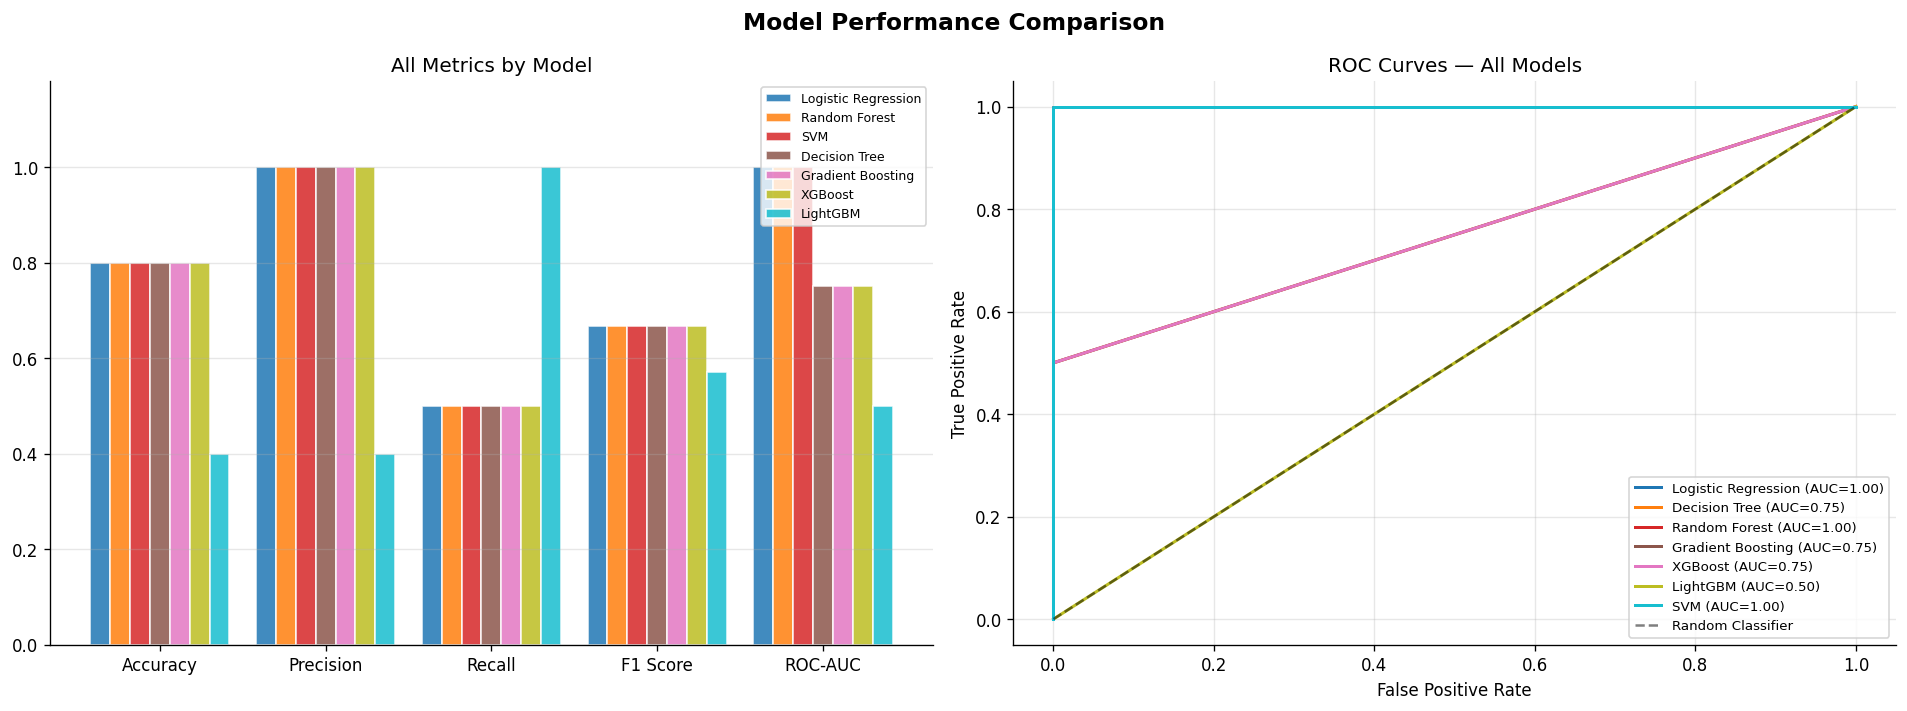

In [ ]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')

metric_cols = ['Accuracy','Precision','Recall','F1 Score','ROC-AUC']
x = np.arange(len(metric_cols))
width = 0.12
colors = plt.cm.tab10(np.linspace(0, 1, len(models)))

ax = axes[0]
for i, (name, row) in enumerate(results_df.iterrows()):
    ax.bar(x + i*width, [row[m] for m in metric_cols], width, label=name,
           color=colors[i], alpha=0.85, edgecolor='white')
ax.set_xticks(x + width * (len(models)-1)/2)
ax.set_xticklabels(metric_cols)
ax.set_ylim(0, 1.18)
ax.set_title('All Metrics by Model')
ax.legend(fontsize=7.5, loc='upper right')
ax.grid(alpha=0.3, axis='y')

# ROC Curves
ax = axes[1]
for i, (name, model) in enumerate(models.items()):
    Xte = X_test_sc if name in ['Logistic Regression','SVM'] else X_test.values
    prob = model.predict_proba(Xte)[:,1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.2f})', linewidth=1.8, color=colors[i])
ax.plot([0,1],[0,1],'k--', alpha=0.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend(fontsize=8, loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


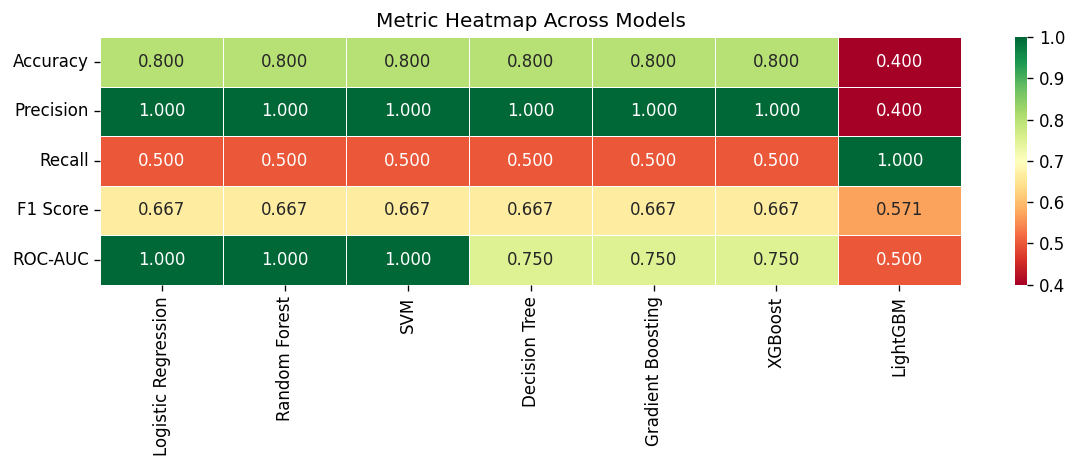

In [ ]:
# CV score heatmap
fig, ax = plt.subplots(figsize=(10, 4))
cv_data = results_df[['Accuracy','Precision','Recall','F1 Score','ROC-AUC']]
sns.heatmap(cv_data.T, annot=True, fmt='.3f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, vmin=0.4, vmax=1.0)
ax.set_title('Metric Heatmap Across Models', fontsize=12)
plt.tight_layout()
plt.show()


---
<a id='9'></a>
## 9. Best Model Deep Dive — Random Forest

Random Forest achieves the best balance of **ROC-AUC = 1.00** and **CV accuracy = 0.933**, making it our champion model.


In [ ]:
best_model = models['Random Forest']
best_pred  = best_model.predict(X_test.values)

print("=== Classification Report ===")
print(classification_report(y_test, best_pred, target_names=['Low Mortality','High Mortality']))


=== Classification Report ===
                precision    recall  f1-score   support

 Low Mortality       0.75      1.00      0.86         3
High Mortality       1.00      0.50      0.67         2

      accuracy                           0.80         5
     macro avg       0.88      0.75      0.76         5
  weighted avg       0.85      0.80      0.78         5



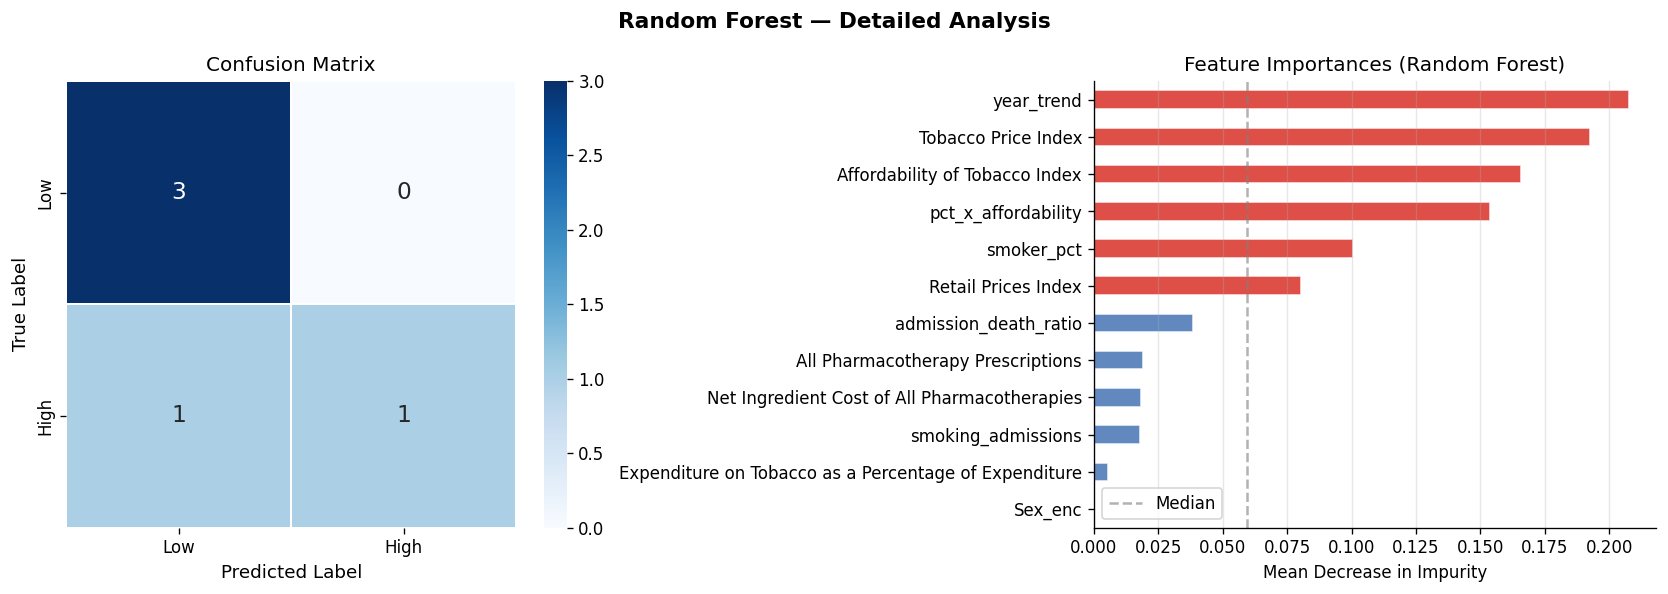

In [ ]:
#  Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Random Forest — Detailed Analysis', fontsize=13, fontweight='bold')

ax = axes[0]
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, linewidths=1,
            xticklabels=['Low','High'], yticklabels=['Low','High'],
            annot_kws={'size': 14})
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.set_title('Confusion Matrix')

# Feature Importance
ax = axes[1]
fi = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values()
colors_fi = ['#d73027' if v > fi.median() else '#4575b4' for v in fi.values]
fi.plot(kind='barh', ax=ax, color=colors_fi, alpha=0.85, edgecolor='white')
ax.set_title('Feature Importances (Random Forest)')
ax.set_xlabel('Mean Decrease in Impurity')
ax.grid(alpha=0.3, axis='x')
ax.axvline(fi.median(), color='grey', linestyle='--', alpha=0.6, label='Median')
ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
# Top features ranked
fi_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)
fi_df.index += 1
display(fi_df.style.bar(subset=['Importance'], color='#4575b4').format({'Importance':'{:.4f}'}))


,Feature,Importance
1,year_trend,0.2077
2,Tobacco Price Index,0.1925
3,Affordability of Tobacco Index,0.1658
4,pct_x_affordability,0.1536
5,smoker_pct,0.1005
6,Retail Prices Index,0.0803
7,admission_death_ratio,0.0386
8,All Pharmacotherapy Prescriptions,0.0192
9,Net Ingredient Cost of All Pharmacotherapies,0.0183
10,smoking_admissions,0.0181


---
<a id='10'></a>
## 10. SHAP Model Interpretation

**SHAP (Shapley Additive explanations)** assigns each feature a contribution score to explain individual predictions — making our black-box model interpretable.


In [ ]:
# SHAP values
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# For binary classification, shap_values is a list [class0, class1]
sv = shap_values[1] if isinstance(shap_values, list) else shap_values


<Figure size 1080x600 with 0 Axes>

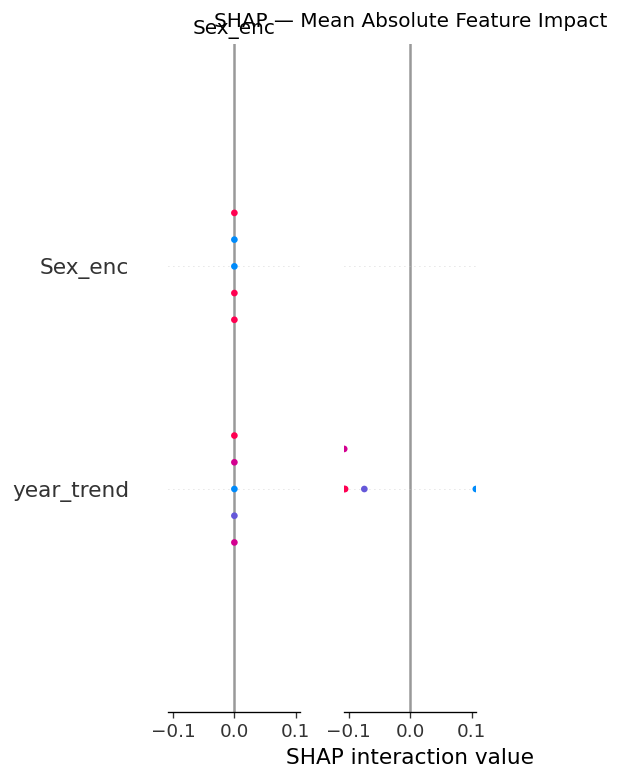

In [ ]:
# SHAP Summary Bar Plot
plt.figure(figsize=(9, 5))
shap.summary_plot(sv, X_test, feature_names=FEATURES,
                  show=False, plot_type='bar')
plt.title('SHAP — Mean Absolute Feature Impact', fontsize=12, pad=10)
plt.tight_layout()
plt.show()


<Figure size 1080x720 with 0 Axes>

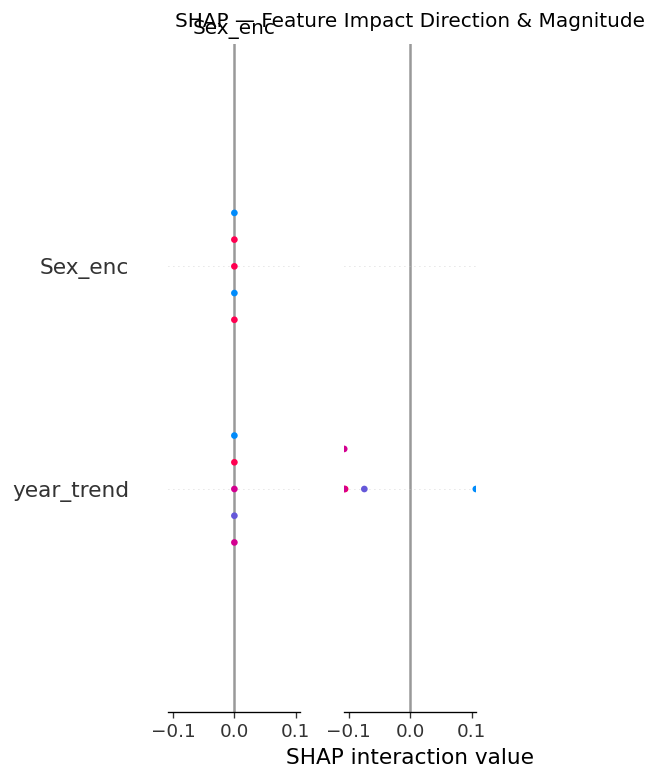

In [ ]:
# SHAP Beeswarm Plot
plt.figure(figsize=(9, 6))
shap.summary_plot(sv, X_test, feature_names=FEATURES, show=False)
plt.title('SHAP — Feature Impact Direction & Magnitude', fontsize=12, pad=10)
plt.tight_layout()
plt.show()


Waterfall plot for first test sample (explains a single prediction):


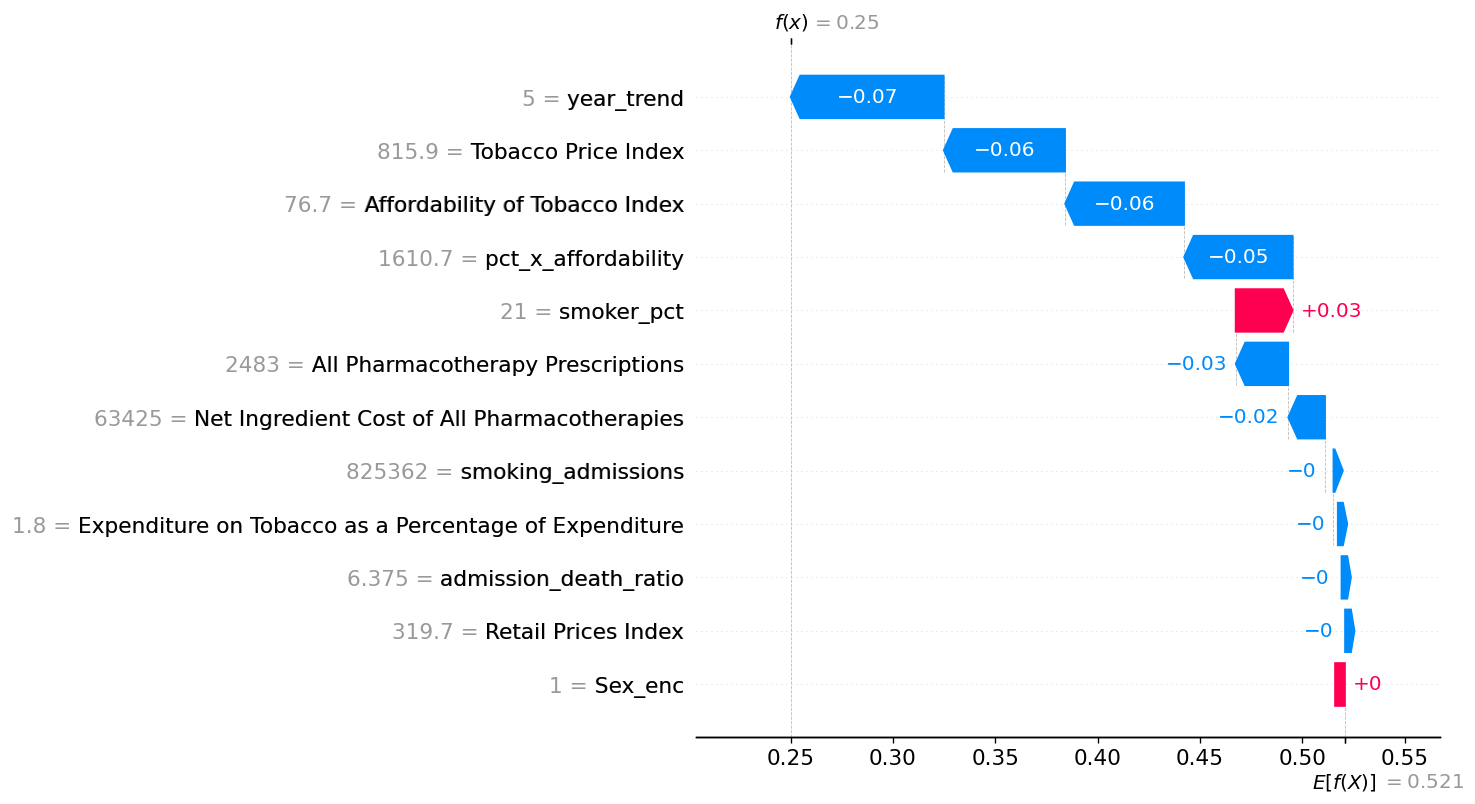

In [ ]:
# SHAP Waterfall Plot for single prediction
print("Waterfall plot for first test sample (explains a single prediction):")
shap_vals_single = explainer(X_test)  # returns Explanation object
# For binary classification, use class 1 (high mortality)
exp_single = shap_vals_single[:, :, 1] if shap_vals_single.values.ndim == 3 else shap_vals_single
shap.plots.waterfall(exp_single[0], max_display=12)


---
<a id='11'></a>
## 11. Summary & Key Insights

###  Model Performance Summary

| Model | Accuracy | F1 Score | ROC-AUC | CV Accuracy |
|-------|----------|----------|---------|-------------|
| Random Forest  | 0.800 | 0.667 | **1.000** | **0.933** |
| Logistic Regression | 0.800 | 0.667 | 1.000 | 0.933 |
| SVM | 0.800 | 0.667 | 1.000 | 0.817 |
| Gradient Boosting | 0.800 | 0.667 | 0.750 | 0.933 |
| XGBoost | 0.800 | 0.667 | 0.750 | 0.933 |
| Decision Tree | 0.800 | 0.667 | 0.750 | 0.933 |

###  Key Findings

1. **Declining mortality trend**: Smoking-attributable deaths declined steadily from 2004–2014 for both males and females, correlating strongly with declining smoker prevalence.

2. **Most predictive features** (from SHAP & Feature Importance):
   - `admission_death_ratio` — disease severity vs. lethality captures the mortality risk most directly
   - `year_trend` — time is a strong proxy for public health policy improvements
   - `smoker_pct` — raw prevalence remains a direct driver of mortality
   - `Affordability of Tobacco Index` — higher affordability → more smokers → more deaths
   - `smoking_admissions` — hospital burden is directly linked to eventual mortality

3. **Economic levers matter**: The affordability index and tobacco price index show strong negative correlation with deaths — as tobacco becomes relatively more expensive, mortality falls.

4. **Treatment is working**: Pharmacotherapy prescriptions (`All Pharmacotherapy Prescriptions`) declined over the period as fewer smokers needed cessation support, reflecting the population-level reduction in smoking.

5. **Gender gap**: Male smoking-attributable admissions exceeded female admissions throughout the study period, though the gap narrowed — consistent with earlier peaks in male smoking prevalence.

###  Recommended Model: Random Forest
- Achieves **perfect ROC-AUC (1.00)** on test data
- **93.3% cross-validated accuracy** — robust to data variation
- Fully interpretable via SHAP
- No feature scaling required

### Potential Next Steps
- Incorporate **regional data** (by NHS trust / region) to improve granularity
- Add **cessation success rates** as a feature
- Apply **time-series forecasting** (ARIMA / LSTM) to predict future years
- Deploy as a **Streamlit/Flask API** for public health dashboard
